In [212]:
from __future__ import annotations
import operator
from typing import List,Dict,Annotated,TypedDict, Literal,Optional
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
from langsmith import wrappers
from dotenv import load_dotenv
load_dotenv()
import os
from pathlib import Path

In [213]:
model = ChatGroq(
            model="llama-3.3-70b-versatile",
            temperature=0.4,
            api_key=os.getenv("GROQ_API_KEY")
)

In [214]:
class Task(BaseModel):
    id:int
    title:str
    
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3-5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120–450).",
    )
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False
    
class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    audience: str = Field(..., description="Who this blog is for.")
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)

class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None

class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)

class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)
    
class State(TypedDict):
    topic: str
    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str

In [215]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

In [216]:
def router_node(state:State)->Dict:
    topic = state["topic"]
    decider = model.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}")
        ]
    )
    return {
        "needs_research" : decision.needs_research,
        "mode":decision.mode,
        "queries":decision.queries
    }

def route_next(state:State)->str:
    return "research" if state['needs_research'] else "orchestrator"

# def _tavily_search(query:str,max_result:int=5)->List[dict]:
#     tools = TavilySearchResults(max_results=max_result)
#     results = tools.invoke({"query":query})
    
#     normalized:List[dict] = []
#     for r in results or []:
#         normalized.append({
#             "title":r.get("title") or "",
#             "url":r.get("url") or "",
#             "published_at":r.get("content") or r.get("snippet") or "",
#             "source": r.get("source")
#         })
#     return normalized
def _tavily_search(query: str, max_result: int = 5) -> List[Dict]:
    tools = TavilySearchResults(max_results=max_result)
    results = tools.invoke(query)
    normalized: List[Dict] = []
    for r in results[:max_result]:
        normalized.append({
            "title": r.get("title", ""),
            "url": r.get("url", ""),
            "content": (r.get("content") or r.get("snippet") or "")[:200],  # 🔥 limit size
            "source": r.get("source", ""),
            "published_at": r.get("published_at", "")
        })

    return normalized

In [217]:
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state:State)->dict:
    queries = (state.get("queries",[]) or [])
    max_results=6
    raw_results:List[dict]= []
    
    for q in queries:
        raw_results.extend(_tavily_search(q,max_result=max_results))
    if not raw_results:
        return {"evidence": []}
    
    extractor = model.with_structured_output(EvidencePack)
    pack = extractor.invoke([
        SystemMessage(content=RESEARCH_SYSTEM),
        HumanMessage(content=f"Raw results:\n{raw_results}")
    ])
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    return {"evidence":list(dedup.values())}
    
    

In [218]:
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120-550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

def orchestrator(state:State)->Dict:
    try:
        planner = model.with_structured_output(Plan)
        evidence = state.get("evidence", [])
        mode = state.get("mode", "closed_book")
        # model_dump() - used to convert pydantic object into dictionary
        plan = planner.with_structured_output(Plan).invoke([
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(content=(
                        f"""Topic : {state['topic']}\n
                        Mode : {mode}\n\n
                        Evidence : Only for fresh claims;may be empty:\n
                        {[e.model_dump() for e in evidence[:16]]}
                        """
                        )
                
            )
        ])
        return {"plan":plan}
    except Exception as e:
        print(str(e))

In [219]:
def fanout(state:State):
    # for each task creating the 'Send' object 
    workers_list = [Send(
        "workers",
        {
            "task":task,
            "topic":state['topic'],
            "mode":state['mode'],
            "plan":state['plan'].model_dump(),
            "evidence":[e.model_dump() for e in state['evidence']]
        }) 
        for task in state['plan'].tasks]
    
    return workers_list

WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""
def workers(payload:Dict)->Dict:
    task=Task(**payload["task"])
    topic=payload["topic"]
    plan=Plan(**payload["plan"])
    bullets_text = "\n- " + "\n- ".join(task.bullets)
    evidence = [EvidenceItem(**e) for e in payload.get("evidence",[])]
    mode = payload.get("mode","closed_book")
    
    bullets_text = "\n- " + "\n- ".join(task.bullets)
    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"""- {e.title} | {e.url} | {e.published_at or 'date:unknown'}""".strip()
            for e in evidence[:20]
        )
    section = model.invoke(
        [SystemMessage(content=WORKER_SYSTEM),
        HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n")
            )
        ]
    ).content.strip()
    return {"sections":[(task.id,section)]}

In [220]:
# def reducer(state:State)->Dict:
#     title = state['plan'].blog_title
#     body = "\n\n".join(state['sections']).strip()
#     final_markdown = f"# {title}\n\n{body}\n"
    
#     # save the file
#     filename = title.lower().replace(" ","_")+".md"
#     output_path = Path(filename)
#     output_path.write_text(final_markdown,encoding="utf-8")
#     return {"final":final_markdown}

def reducer_node(state: State) -> dict:
    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

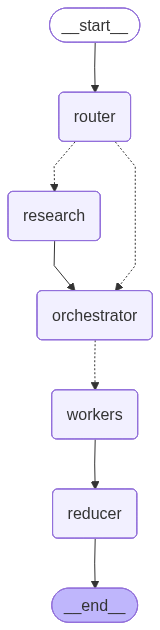

In [221]:
CONFIG={
        "configurable": {"thread_id": "blog-1"},
        "run_name": "blog-writing-agent"
}

graph = StateGraph(State)

g = StateGraph(State)

graph.add_node("router", router_node)
graph.add_node("research", research_node)
graph.add_node("orchestrator", orchestrator)
graph.add_node("workers", workers)
graph.add_node("reducer", reducer_node)
# edges
graph.add_edge(START,"router")
graph.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
graph.add_edge("research", "orchestrator")

graph.add_conditional_edges("orchestrator", fanout, ["workers"])
graph.add_edge("workers","reducer")
graph.add_edge("reducer",END)

app = graph.compile()
app

In [222]:
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out


In [223]:
run("State of Multimodal LLMs in 2026")

'RunnableSequence' object has no attribute 'with_structured_output'


AttributeError: 'NoneType' object has no attribute 'tasks'